In [3]:
import pandas as pd
import matplotlib.pyplot as plt


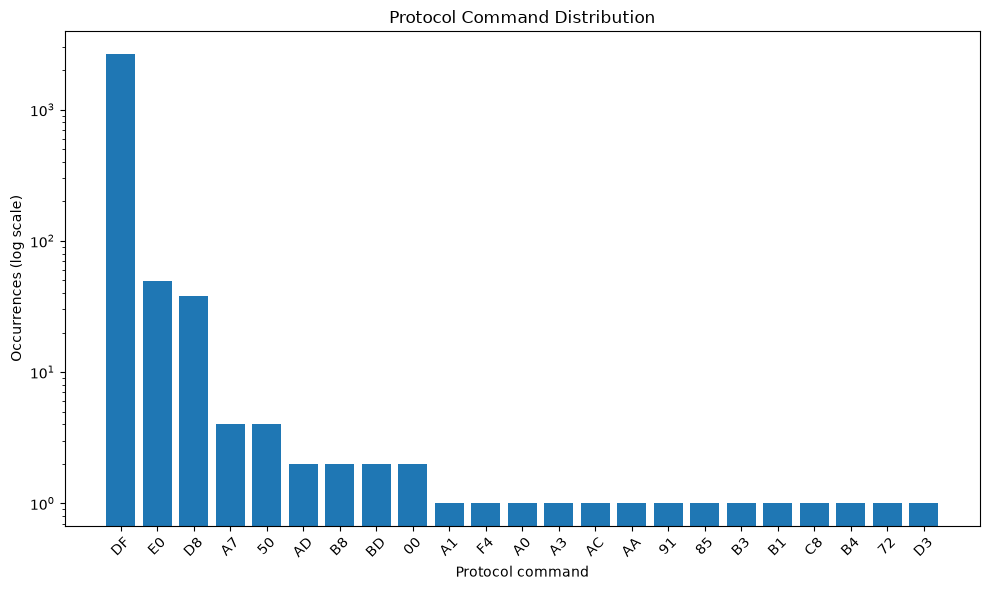

In [4]:

df = pd.read_csv("../data/processed/protocol_rows.csv")

command_counts = (
    df["command"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
plt.bar(command_counts.index, command_counts.values)

plt.yscale("log")
plt.xlabel("Protocol command")
plt.ylabel("Occurrences (log scale)")
plt.title("Protocol Command Distribution")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
df.head()

,timestamp,source_file,command,message,line_no
0,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||695:-->watch::::::>device...,2
1,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||722:-->watch::::::>device...,21
2,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||740:-->watch::::::>device...,40
3,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||759:-->watch::::::>device...,59
4,2026-08-09 07:05:27,ble_change.txt,AD,2026-08-09 07:05:27||770:-->watch::::::>device...,77


In [6]:
df["timestapm"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df.head()

,timestamp,source_file,command,message,line_no,timestapm
0,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||695:-->watch::::::>device...,2,2026-08-09 07:05:27
1,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||722:-->watch::::::>device...,21,2026-08-09 07:05:27
2,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||740:-->watch::::::>device...,40,2026-08-09 07:05:27
3,2026-08-09 07:05:27,ble_change.txt,A7,2026-08-09 07:05:27||759:-->watch::::::>device...,59,2026-08-09 07:05:27
4,2026-08-09 07:05:27,ble_change.txt,AD,2026-08-09 07:05:27||770:-->watch::::::>device...,77,2026-08-09 07:05:27


In [14]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [15]:
counts = (
    df.set_index("timestamp")
        .groupby("command")
        .resample("1s")
        .size()
        .unstack("command", fill_value=0)
)

counts.head()

command,00,50,72,85,91,A0,A1,A3,A7,AA,...,B3,B4,B8,BD,C8,D3,D8,DF,E0,F4
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-08-09 07:05:27,0,0,0,0,0,0,1,0,4,0,...,0,0,2,1,0,0,0,0,0,0
2026-08-09 07:05:28,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2026-08-09 07:05:29,1,0,0,1,1,0,0,1,0,1,...,1,0,0,0,0,0,0,0,0,0
2026-08-09 07:05:30,1,4,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
2026-08-09 07:05:31,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


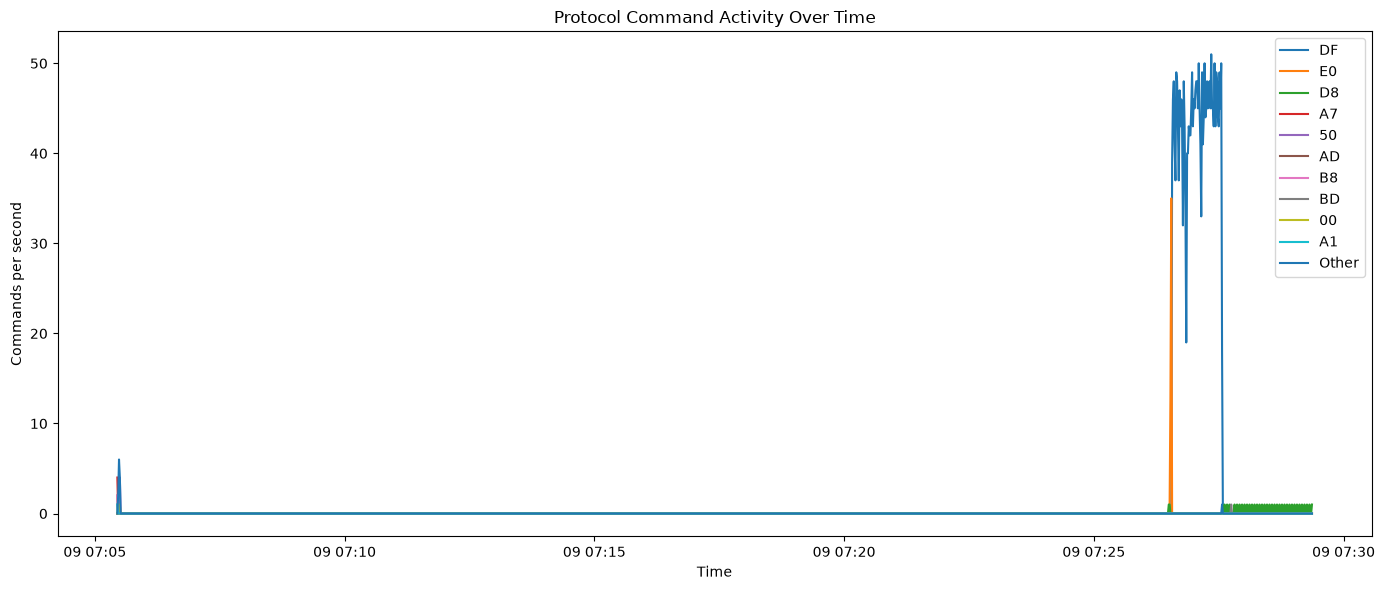

In [24]:
top_commands = (
    df["command"]
    .value_counts()
    .head(10)
    .index
)

plot_data = counts.copy()

other_columns = [
    c for c in plot_data.columns
    if c not in top_commands
]

plot_data["Other"] = plot_data[other_columns].sum(axis=1)

plot_data = plot_data[list(top_commands) + ["Other"]]



plt.figure(figsize=(14, 6))

for command in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[command],
        label=command
    )

plt.xlabel("Time")
plt.ylabel("Commands per second")
plt.title("Protocol Command Activity Over Time")
plt.legend()

plt.tight_layout()
plt.show()


